<a href="https://colab.research.google.com/github/AngelRiosG/Actividad-1-Mongo-DB/blob/main/actividad2Maestria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

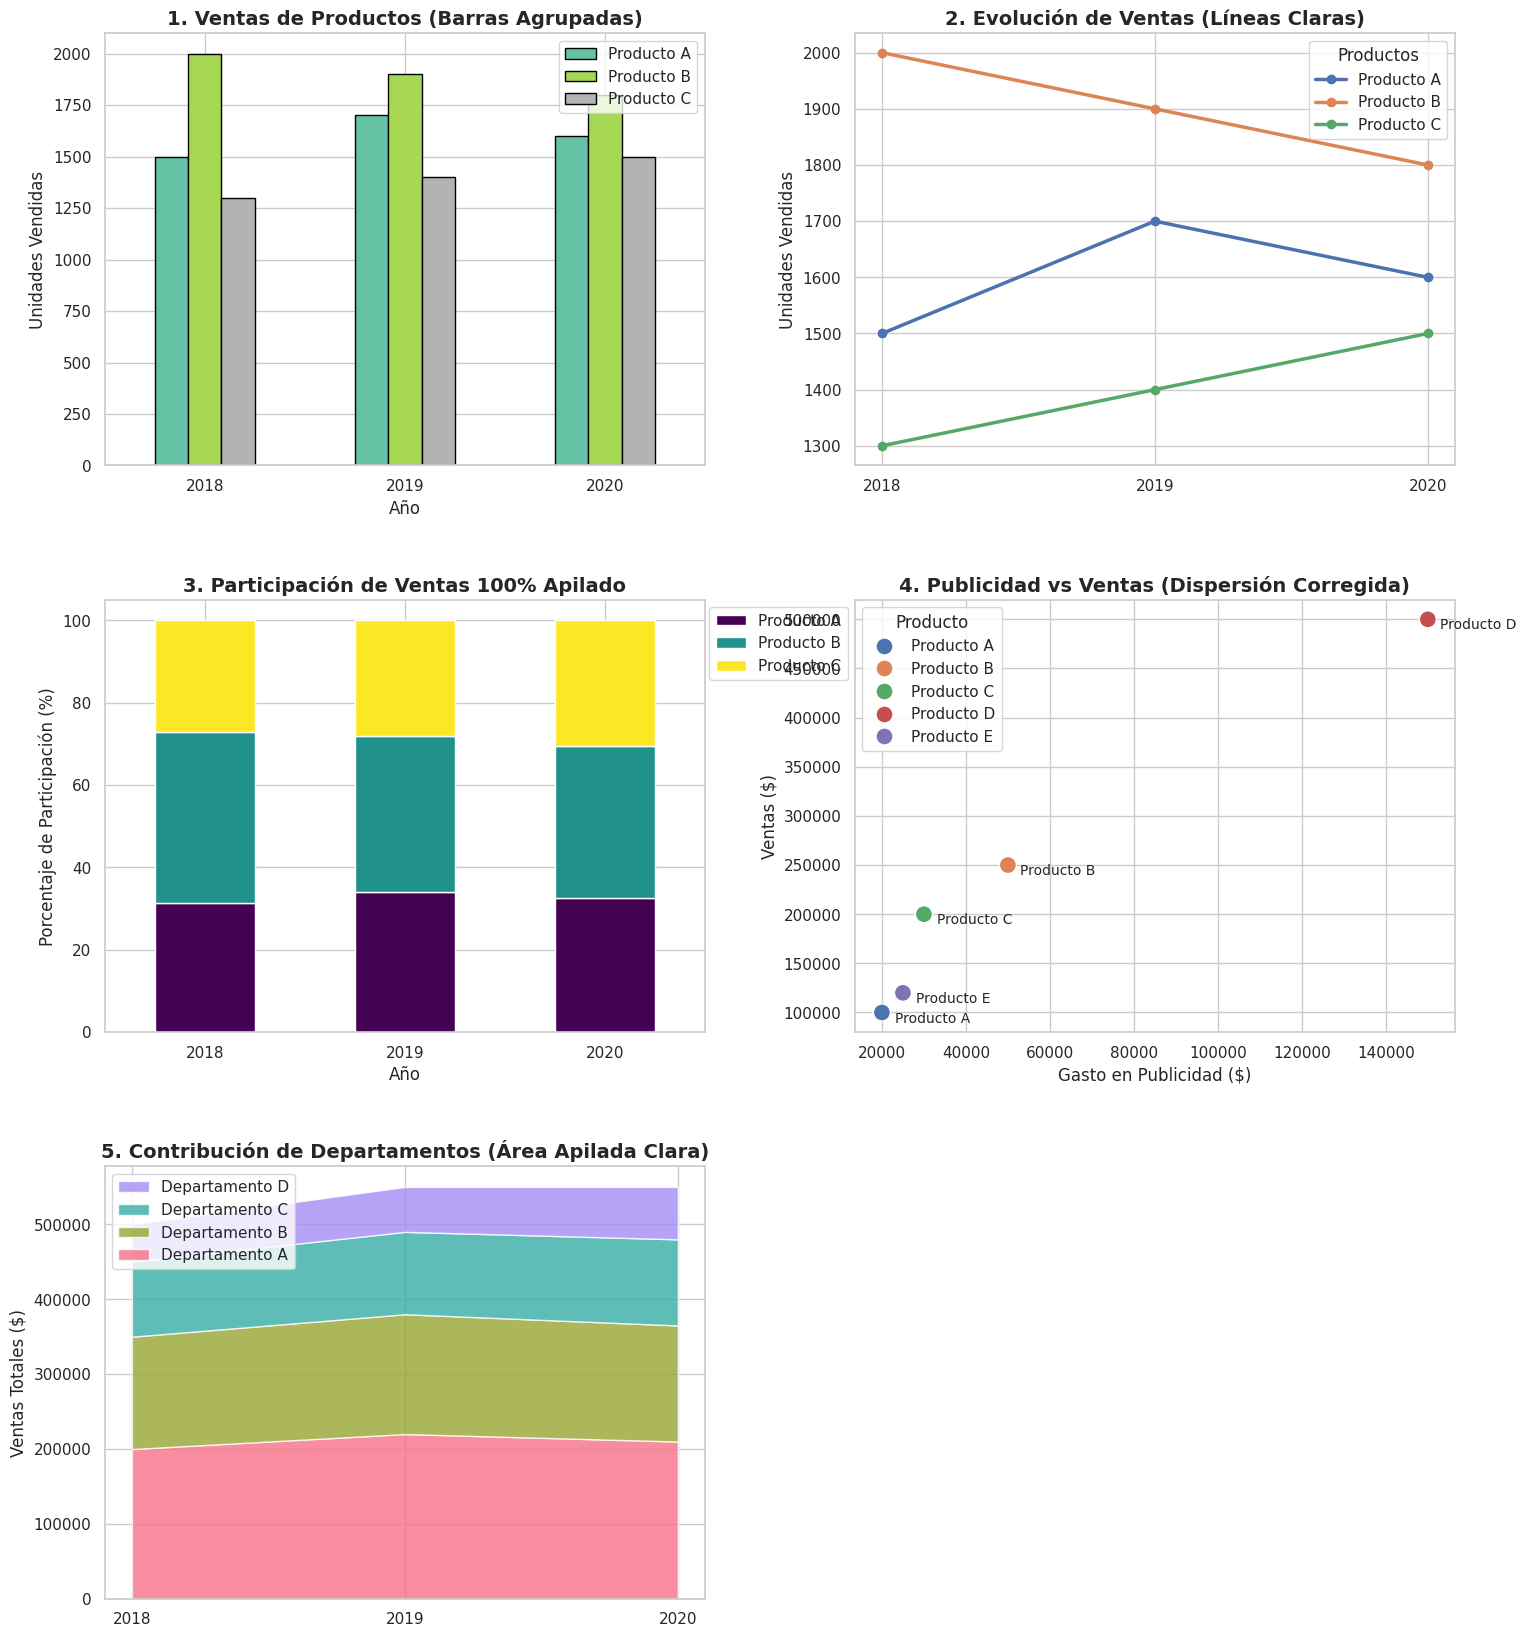

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo general para gráficas más limpias
sns.set_theme(style="whitegrid")

data_ventas = {
    'Año': ['2018', '2019', '2020'],
    'Producto A': [1500, 1700, 1600],
    'Producto B': [2000, 1900, 1800],
    'Producto C': [1300, 1400, 1500]
}
df_ventas = pd.DataFrame(data_ventas).set_index('Año')

# Tabla 2
data_publicidad = {
    'Producto': ['Producto A', 'Producto B', 'Producto C', 'Producto D', 'Producto E'],
    'Gasto en Publicidad ($)': [20000, 50000, 30000, 150000, 25000],
    'Ventas ($)': [100000, 250000, 200000, 500000, 120000]
}
df_publi = pd.DataFrame(data_publicidad)

# Tabla 3
data_dept = {
    'Año': ['2018', '2019', '2020'],
    'Departamento A': [200000, 220000, 210000],
    'Departamento B': [150000, 160000, 155000],
    'Departamento C': [100000, 110000, 115000],
    'Departamento D': [50000, 60000, 70000]
}
df_dept = pd.DataFrame(data_dept).set_index('Año')


# ==========================================
# Generación de Gráficos Mejorados
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.tight_layout(pad=6.0)

# 1. Gráfico de barras agrupadas (Retail)
df_ventas.plot(kind='bar', ax=axes[0,0], colormap='Set2', edgecolor='black')
axes[0,0].set_title('1. Ventas de Productos (Barras Agrupadas)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Unidades Vendidas')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Gráfico de líneas con marcadores claros (SaaS)
for col in df_ventas.columns:
    axes[0,1].plot(df_ventas.index, df_ventas[col], marker='o', linewidth=2.5, label=col)
axes[0,1].set_title('2. Evolución de Ventas (Líneas Claras)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Unidades Vendidas')
axes[0,1].legend(title='Productos')

# 3. Gráfico de barras apiladas al 100% (Utilities)
df_ventas_pct = df_ventas.div(df_ventas.sum(axis=1), axis=0) * 100
df_ventas_pct.plot(kind='bar', stacked=True, ax=axes[1,0], colormap='viridis', edgecolor='white')
axes[1,0].set_title('3. Participación de Ventas 100% Apilado', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Porcentaje de Participación (%)')
axes[1,0].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axes[1,0].tick_params(axis='x', rotation=0)

# 4. Gráfico de dispersión con etiquetas y escalado (Marketing)
sns.scatterplot(data=df_publi, x='Gasto en Publicidad ($)', y='Ventas ($)',
                hue='Producto', s=150, palette='deep', ax=axes[1,1])
# Etiquetando los puntos
for i in range(df_publi.shape[0]):
    axes[1,1].text(df_publi['Gasto en Publicidad ($)'][i] + 3000,
                   df_publi['Ventas ($)'][i] - 10000,
                   df_publi['Producto'][i], fontsize=10)
axes[1,1].set_title('4. Publicidad vs Ventas (Dispersión Corregida)', fontsize=14, fontweight='bold')

# 5. Gráfico de área apilada optimizado (Finanzas)
axes[2,0].stackplot(df_dept.index, df_dept.T, labels=df_dept.columns, alpha=0.8, colors=sns.color_palette("husl", 4))
axes[2,0].set_title('5. Contribución de Departamentos (Área Apilada Clara)', fontsize=14, fontweight='bold')
axes[2,0].set_ylabel('Ventas Totales ($)')
axes[2,0].legend(loc='upper left', reverse=True)

# Ocultar el último subplot vacío
axes[2,1].axis('off')

plt.show()